In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import to_undirected

# BEFORE YOU RUN
## Data Structure Should be:
### data /
###        cyber_dataset
####                    /auth.txt.gs * very large, working on getting a workable version
####                    /redteam.txt.gz
###        elliptic_bitcoin_dataset
####                               /elliptic_txs_classes.csv
####                               /elliptic_txs_edgelist.csv
####                               /elliptic_txs_features.csv
###        keystroke_dynamics_dataset/DSL-StrongPasswordData.csv

About the Data:
- Elliptic is already a graph. It has 2% illicit data, the rest is licit.
- Few things to check out: is the data clustered in specific time windows or not?

- For device/auth signals, this data is pretty massive. We need to downsample to be able to manage number of users.
- We can explore how many users log into a single machine. Maybe a "normal" number of devices per user, things like that

- Behavioral data is micro-features for the nodes. We can analyze the variance in keystoke hold times. Maybe some sort of behavioral fingerprint for a user that changes when an account is compromised.

Mapping the Data
- These obviouslly aren't natively connected, we need to do this ourselves. For example, User_ID -> Wallet_ID and Device_ID -> Login_Session or something like that.
- This could help us map User A logs in from Device B (unusual) with a typing cadence that doesn't match their profile, then immediately sends Bitcoin to an Illicit node in the Elliptic graph

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ln -s "/content/drive/MyDrive/data" /content/data

In [4]:
# Read in the Datasets
df_labels = pd.read_csv('data/elliptic_bitcoin_dataset/elliptic_txs_classes.csv') # maps transaction IDs to licit, illicit, unknown
df_edges = pd.read_csv('data/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv') # the adjacency list [who sent money to who]
df_features = pd.read_csv('data/elliptic_bitcoin_dataset/elliptic_txs_features.csv', header=None) # 166 features for each transaction

In [5]:
# 1. Rename columns for clarity
# The features file usually doesn't have headers. Column 0 is the ID, Column 1 is Time Step.
df_features.columns = ['txId', 'time_step'] + [f'feat_{i}' for i in range(165)]

# 2. Merge labels and features into a master Node Dataframe
df_nodes = pd.merge(df_features, df_labels, on='txId')

In [6]:
class_map = {'1': 1, '2': 0, 'unknown': -1}
df_nodes['class'] = df_nodes['class'].map(class_map)
print(df_nodes['class'].value_counts())
# We have a lot of unknown nodes we can work with. Train on the known ones and see if we can classify the unknowns later

class
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64


In [11]:
# graph density
num_nodes = df_nodes.shape[0]
num_edges = df_edges.shape[0]
density = num_edges / (num_nodes * (num_nodes - 1))
print(f"Graph Density: {density:.6f}")
#sparse graph is excpected for real world networks, network is highly efficient.

Graph Density: 0.000006


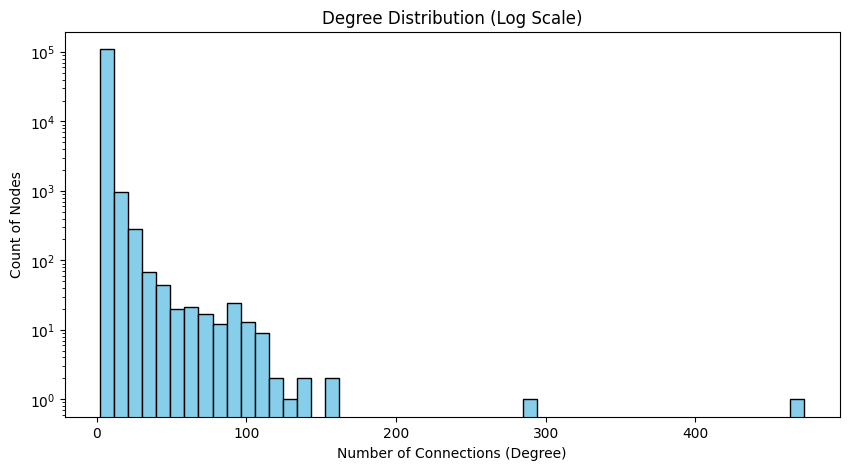

In [13]:
# Calculate degree for each node
# In-degree: how many transactions flow INTO this tx
# Out-degree: how many transactions flow OUT of this tx
degrees = df_edges['txId1'].value_counts() + df_edges['txId2'].value_counts()

plt.figure(figsize=(10, 5))
plt.hist(degrees, bins=50, log=True, color='skyblue', edgecolor='black')
plt.title("Degree Distribution (Log Scale)")
plt.xlabel("Number of Connections (Degree)")
plt.ylabel("Count of Nodes")
plt.show()

Interpreting with some context here:
- the average degree is 1.15ish, meaning that any node with a degree of 10, 20, or more, is likely a major outlier and this represents mixing services or consolidation points
- Because of sparsity, we should use GraphSAGE or GCN because it aggregates neighbors information without being overwhelmed by noise.

- Another thing, isolated clusters can be highly suspicious. There are a lot of disjointed clusters in this data. So, most nodes do not see each other. We need to rely on local neighborhood features because of this!

In [14]:
# 1. Create the Graph object from your edgelist
G = nx.from_pandas_edgelist(df_edges, source='txId1', target='txId2', create_using=nx.Graph())

# 2. Find all connected components
components = list(nx.connected_components(G))

# 3. Sort components by size (largest first)
components.sort(key=len, reverse=True)

# 4. Get the Largest Connected Component
lcc = G.subgraph(components[0])

print(f"Total nodes in full graph: {G.number_of_nodes()}")
print(f"Nodes in the Largest Connected Component: {lcc.number_of_nodes()}")
print(f"Percentage of nodes in LCC: {100 * lcc.number_of_nodes() / G.number_of_nodes():.2f}%")

Total nodes in full graph: 203769
Nodes in the Largest Connected Component: 7880
Percentage of nodes in LCC: 3.87%


In [15]:
# Create a mapping of txId to class for quick lookup
node_class_dict = dict(zip(df_nodes['txId'], df_nodes['class']))

# Analyze the top 10 largest components
for i, comp in enumerate(components[:10]):
    # Count classes in this component
    classes_in_comp = [node_class_dict.get(node, -1) for node in comp]

    fraud_count = classes_in_comp.count(1)
    licit_count = classes_in_comp.count(0)
    unknown_count = classes_in_comp.count(-1)

    print(f"Component {i+1} | Size: {len(comp)} | Fraud: {fraud_count} | Licit: {licit_count} | Unknown: {unknown_count}")

Component 1 | Size: 7880 | Fraud: 17 | Licit: 2130 | Unknown: 5733
Component 2 | Size: 7140 | Fraud: 239 | Licit: 1915 | Unknown: 4986
Component 3 | Size: 6803 | Fraud: 8 | Licit: 1874 | Unknown: 4921
Component 4 | Size: 6727 | Fraud: 18 | Licit: 954 | Unknown: 5755
Component 5 | Size: 6621 | Fraud: 11 | Licit: 1268 | Unknown: 5342
Component 6 | Size: 6393 | Fraud: 33 | Licit: 1675 | Unknown: 4685
Component 7 | Size: 6048 | Fraud: 102 | Licit: 1101 | Unknown: 4845
Component 8 | Size: 5894 | Fraud: 158 | Licit: 1605 | Unknown: 4131
Component 9 | Size: 5693 | Fraud: 30 | Licit: 1410 | Unknown: 4253
Component 10 | Size: 5598 | Fraud: 5 | Licit: 1216 | Unknown: 4377


In [ ]:
# we could use this to create risk scores for unknown nodes based on their proximity to known fraudulent nodes in the graph.

GNN baseline model

In [16]:
import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cpu
cuda available: False


In [18]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.0 MB/s eta 0:00:00


In [19]:
import torch_geometric
print("pyg:", torch_geometric.__version__)

pyg: 2.7.0


In [44]:
# build standardized node feature matrix x
feat_cols = [c for c in df_nodes.columns if c.startswith("feat_")]
print("num features:", len(feat_cols))

scaler_gnn = StandardScaler()
X_scaled = scaler_gnn.fit_transform(df_nodes[feat_cols])

x = torch.tensor(X_scaled, dtype=torch.float32)
print("x shape:", x.shape)

num features: 165
x shape: torch.Size([203769, 165])


In [21]:
# y:{-1:unknown, 0:licit, 1: ilicit}
y = torch.tensor(df_nodes["class"].values, dtype=torch.long)
print("label counts:", {v:int((y==v).sum()) for v in [-1,0,1]})

label counts: {-1: 157205, 0: 42019, 1: 4545}


In [22]:
#convert edges into edge_index
from torch_geometric.utils import to_undirected

tx_ids = df_nodes["txId"].values
id_to_idx = {t:i for i,t in enumerate(tx_ids)}

src = df_edges["txId1"].map(id_to_idx)
dst = df_edges["txId2"].map(id_to_idx)

mask = src.notna() & dst.notna()
src = src[mask].astype(int).values
dst = dst[mask].astype(int).values

edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long)
edge_index = to_undirected(edge_index)

print("edge_index shape:", edge_index.shape)

edge_index shape: torch.Size([2, 468710])


In [24]:
from torch_geometric.data import Data
data = Data(x=x, edge_index=edge_index, y=y)
data

Data(x=[203769, 165], edge_index=[2, 468710], y=[203769])

In [26]:
time_step = df_nodes["time_step"].values
known = df_nodes["class"].values != -1

train_mask = (time_step <= 34) & known
val_mask   = (time_step >= 35) & (time_step <= 39) & known
test_mask  = (time_step >= 40) & known

data.train_mask = torch.tensor(train_mask, dtype=torch.bool)
data.val_mask   = torch.tensor(val_mask, dtype=torch.bool)
data.test_mask  = torch.tensor(test_mask, dtype=torch.bool)

print("train:", int(data.train_mask.sum()),
      "val:", int(data.val_mask.sum()),
      "test:", int(data.test_mask.sum()))

train: 29894 val: 5486 test: 11184


In [41]:
#build tabulaar baseline
feature_cols = [c for c in df_nodes.columns if c.startswith("feat_")]

X_train = df_nodes.loc[train_mask, feature_cols]
y_train_tab = df_nodes.loc[train_mask, "class"]

X_val = df_nodes.loc[val_mask, feature_cols]
y_val_tab = df_nodes.loc[val_mask, "class"]

X_test = df_nodes.loc[test_mask, feature_cols]
y_test_tab = df_nodes.loc[test_mask, "class"]

print("X_train:", X_train.shape, "y_train:", y_train_tab.shape)
print("X_val:", X_val.shape, "y_val:", y_val_tab.shape)
print("X_test:", X_test.shape, "y_test:", y_test_tab.shape)

X_train: (29894, 165) y_train: (29894,)
X_val: (5486, 165) y_val: (5486,)
X_test: (11184, 165) y_test: (11184,)


In [42]:
#logistic regression baseline
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

log_reg.fit(X_train, y_train_tab)

p_val_lr = log_reg.predict_proba(X_val)[:, 1]
p_test_lr = log_reg.predict_proba(X_test)[:, 1]

print("LogReg VAL AUC:", roc_auc_score(y_val_tab, p_val_lr))
print("LogReg VAL PR-AUC:", average_precision_score(y_val_tab, p_val_lr))
print("LogReg TEST AUC:", roc_auc_score(y_test_tab, p_test_lr))
print("LogReg TEST PR-AUC:", average_precision_score(y_test_tab, p_test_lr))

LogReg VAL AUC: 0.920131253626634
LogReg VAL PR-AUC: 0.44067384292009726
LogReg TEST AUC: 0.8531932787639851
LogReg TEST PR-AUC: 0.22049514835285777


In [43]:
#XGBoost baseline
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train_tab)

p_val_xgb = xgb.predict_proba(X_val)[:, 1]
p_test_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGB VAL AUC:", roc_auc_score(y_val_tab, p_val_xgb))
print("XGB VAL PR-AUC:", average_precision_score(y_val_tab, p_val_xgb))
print("XGB TEST AUC:", roc_auc_score(y_test_tab, p_test_xgb))
print("XGB TEST PR-AUC:", average_precision_score(y_test_tab, p_test_xgb))

XGB VAL AUC: 0.9909924068773632
XGB VAL PR-AUC: 0.9624134841567156
XGB TEST AUC: 0.8904580855889697
XGB TEST PR-AUC: 0.6739026645866315


In [45]:
#define GNN model
class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.lin = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        return self.lin(x).squeeze()

In [51]:
device = torch.device("cpu")
model = GraphSAGE(data.x.shape[1], hidden_dim=256, dropout=0.3).to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [52]:
train_y = data.y[data.train_mask]

pos = (train_y == 1).sum()
neg = (train_y == 0).sum()

pos_weight = torch.tensor([neg / pos], dtype=torch.float)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [53]:
def evaluate(mask):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        probs = torch.sigmoid(logits)

    y_true = data.y[mask].cpu().numpy()
    p = probs[mask].cpu().numpy()

    auc = roc_auc_score(y_true, p)
    ap = average_precision_score(y_true, p)
    return auc, ap

best_val_ap = -1
best_state = None

for epoch in range(1, 50):
    model.train()
    optimizer.zero_grad()

    logits = model(data.x, data.edge_index)
    logits_train = logits[data.train_mask]
    y_train = data.y[data.train_mask].float()

    loss = criterion(logits_train, y_train)
    loss.backward()
    optimizer.step()

    val_auc, val_ap = evaluate(data.val_mask)

    if val_ap > best_val_ap:
        best_val_ap = val_ap
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch:02d} | loss={loss.item():.4f} | val AUC={val_auc:.4f} | val PR-AUC={val_ap:.4f}")

Epoch 01 | loss=1.2119 | val AUC=0.8051 | val PR-AUC=0.3435
Epoch 02 | loss=1.0760 | val AUC=0.8365 | val PR-AUC=0.4301
Epoch 03 | loss=0.9935 | val AUC=0.8540 | val PR-AUC=0.4618
Epoch 04 | loss=0.9127 | val AUC=0.8650 | val PR-AUC=0.4787
Epoch 05 | loss=0.8337 | val AUC=0.8703 | val PR-AUC=0.4805
Epoch 06 | loss=0.7673 | val AUC=0.8715 | val PR-AUC=0.4732
Epoch 07 | loss=0.7026 | val AUC=0.8711 | val PR-AUC=0.4655
Epoch 08 | loss=0.6412 | val AUC=0.8701 | val PR-AUC=0.4649
Epoch 09 | loss=0.5892 | val AUC=0.8686 | val PR-AUC=0.4682
Epoch 10 | loss=0.5471 | val AUC=0.8672 | val PR-AUC=0.4737
Epoch 11 | loss=0.5118 | val AUC=0.8666 | val PR-AUC=0.4801
Epoch 12 | loss=0.4892 | val AUC=0.8673 | val PR-AUC=0.4879
Epoch 13 | loss=0.4807 | val AUC=0.8699 | val PR-AUC=0.4990
Epoch 14 | loss=0.4710 | val AUC=0.8744 | val PR-AUC=0.5131
Epoch 15 | loss=0.4619 | val AUC=0.8804 | val PR-AUC=0.5309
Epoch 16 | loss=0.4546 | val AUC=0.8876 | val PR-AUC=0.5520
Epoch 17 | loss=0.4397 | val AUC=0.8952 

In [54]:
model.load_state_dict(best_state)

test_auc_gnn, test_ap_gnn = evaluate(data.test_mask)

print("GraphSAGE TEST AUC:", test_auc_gnn)
print("GraphSAGE TEST PR-AUC:", test_ap_gnn)

GraphSAGE TEST AUC: 0.8492658896258614
GraphSAGE TEST PR-AUC: 0.48201624394673037


In [55]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost", "GraphSAGE"],
    "Type": ["Tabular", "Tabular", "Graph"],
    "Test AUC": [
        roc_auc_score(y_test_tab, p_test_lr),
        roc_auc_score(y_test_tab, p_test_xgb),
        test_auc_gnn
    ],
    "Test PR-AUC": [
        average_precision_score(y_test_tab, p_test_lr),
        average_precision_score(y_test_tab, p_test_xgb),
        test_ap_gnn
    ]
})

results

,Model,Type,Test AUC,Test PR-AUC
0,Logistic Regression,Tabular,0.853193,0.220495
1,XGBoost,Tabular,0.890458,0.673903
2,GraphSAGE,Graph,0.849266,0.482016
